In [ ]:
!pip install ucimlrepo phik

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik.report import plot_correlation_matrix
from ucimlrepo import fetch_ucirepo

# Fetch the dataset from UCI
dataset = fetch_ucirepo(id=697)

# Extract features and targets
X = dataset.data.features
y = dataset.data.targets

# Combine into a single DataFrame
df = pd.concat([X, y], axis=1)

print(f"Original dataset shape: {df.shape}")
print(df['Target'].value_counts())

Original dataset shape: (4424, 37)
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [ ]:
# Filter out 'Enrolled' status
df = df[df['Target'].isin(['Graduate', 'Dropout'])].copy()

# Convert Target to binary outcome (Dropout: 0, Graduate: 1)
df['Target'] = df['Target'].map({'Dropout': 0, 'Graduate': 1})

print(f"Filtered dataset shape: {df.shape}")

Filtered dataset shape: (3630, 37)


In [ ]:
# Explicitly define the continuous columns based on Table 1 of the paper
continuous_columns = [
    'Previous qualification (grade)',
    'Admission grade',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

# Calculate Phi-K correlation matrix, explicitly passing the continuous columns
phik_matrix = df.phik_matrix(interval_cols=continuous_columns)

# Get correlations with the Target variable
target_correlations = phik_matrix['Target'].drop('Target')

# Print the correlations sorted highest to lowest to compare with the paper
print("Phi-K Correlations with Target:")
print(target_correlations.sort_values(ascending=False).to_string())

# Filter variables with correlation >= 0.4
selected_features = target_correlations[target_correlations >= 0.4].index.tolist()

print("\nFeatures meeting the >= 0.4 threshold:")
for feature in selected_features:
    print(f"- {feature}")

Phi-K Correlations with Target:
Curricular units 2nd sem (approved)               0.889721
Curricular units 2nd sem (grade)                  0.772135
Curricular units 1st sem (approved)               0.763560
Curricular units 1st sem (grade)                  0.679049
Tuition fees up to date                           0.638704
Scholarship holder                                0.470679
Curricular units 2nd sem (evaluations)            0.468916
Curricular units 1st sem (evaluations)            0.454206
Age at enrollment                                 0.434453
Application mode                                  0.408076
Debtor                                            0.405548
Gender                                            0.383914
Course                                            0.382446
Curricular units 2nd sem (enrolled)               0.360453
Curricular units 1st sem (enrolled)               0.328991
Father's qualification                            0.224723
Previous qualification  

interval columns not set, guessing: ['Target', 'Course', 'Tuition fees up to date', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']


<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_6187/3081719403.py:13: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Reproduced Figure 1: $\phi_k$ Correlation Matrix")


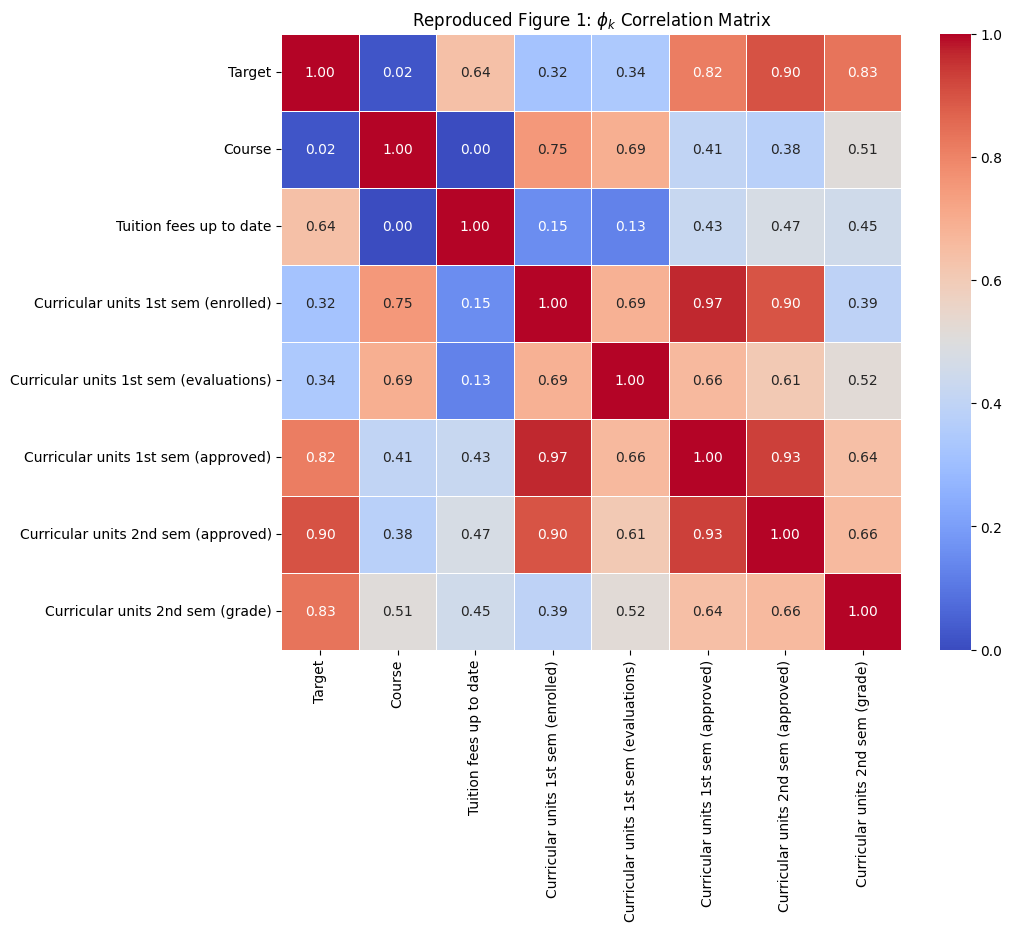

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# The paper's Figure 1 only shows the Target and the 7 final features
fig1_columns = ['Target'] + paper_features

# Calculate the matrix for only these specific columns
fig1_matrix = df[fig1_columns].phik_matrix()

# Plot the matrix to match the paper's visual style
plt.figure(figsize=(10, 8))
sns.heatmap(fig1_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=0, vmax=1)
plt.title("Reproduced Figure 1: $\phi_k$ Correlation Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# The exact 7 features stated in the paper's Results section
paper_features = [
    'Course',
    'Tuition fees up to date',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)'
]

# Force the dataframe to use ONLY these features
X_final = df[paper_features]
y_final = df['Target']

# The paper specifies a 30% testing set and 70% training set
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.30,
    random_state=42 # Setting a random state for reproducibility
)

print("Features utilized for model training:")
for feature in X_final.columns:
    print(f"- {feature}")

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Features utilized for model training:
- Course
- Tuition fees up to date
- Curricular units 1st sem (enrolled)
- Curricular units 1st sem (evaluations)
- Curricular units 1st sem (approved)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (grade)

Training data shape: (2541, 7)
Testing data shape: (1089, 7)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_and_visualize(model, X_test, y_test, model_name):
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # 1. Calculate Metrics
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred) * 100
    rec = recall_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred) * 100

    print(f"--- {model_name} Test Metrics ---")
    print(f"Accuracy:  {acc:.0f}%")
    print(f"Precision: {prec:.0f}%")
    print(f"Recall:    {rec:.0f}%")
    print(f"F1 Score:  {f1:.0f}%\n")

    # 2. Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dropout (0)', 'Graduate (1)'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    disp.plot(ax=axes[0], cmap='rocket') # 'rocket' cmap closely matches the paper's dark/red theme
    axes[0].set_title(f'{model_name} - Confusion Matrix')

    # 3. Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'AUC = {roc_auc:.2f}')
    axes[1].plot([0, 1], [0, 1], color='red', lw=1.5, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Receiver Operating Characteristic')
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:52:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Tuned XGBoost Test Metrics ---
Accuracy:  90%
Precision: 89%
Recall:    96%
F1 Score:  92%



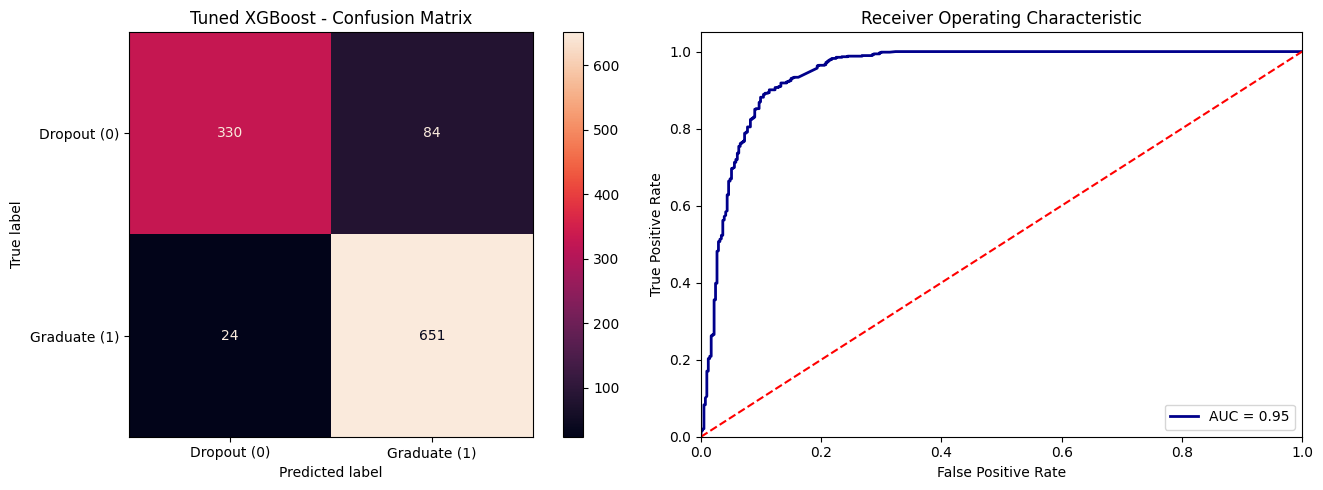

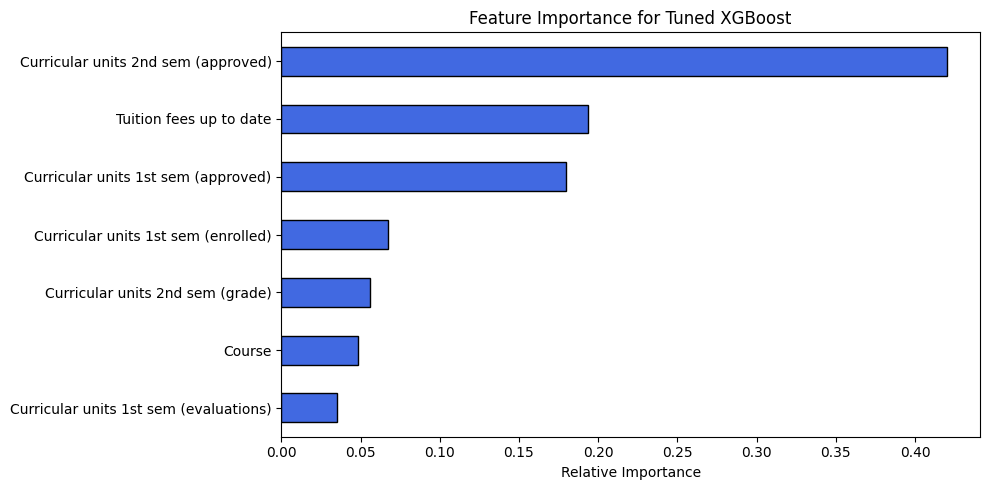

In [ ]:
from xgboost import XGBClassifier
import pandas as pd

# Initialize the XGBoost Classifier with tuned parameters
# These parameters help prevent overfitting and improve generalization
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model
xgb_model.fit(X_train, y_train)

# Evaluate and plot standard metrics
evaluate_and_visualize(xgb_model, X_test, y_test, "Tuned XGBoost")

# 4. Plot Feature Importance for XGBoost
plt.figure(figsize=(10, 5))
feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
# Sort to match the visual style of the paper
feature_importances.sort_values(ascending=True).plot(kind='barh', color='royalblue', edgecolor='black')
plt.title('Feature Importance for Tuned XGBoost')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

--- Stacking Classifier Test Metrics ---
Accuracy:  90%
Precision: 88%
Recall:    97%
F1 Score:  92%



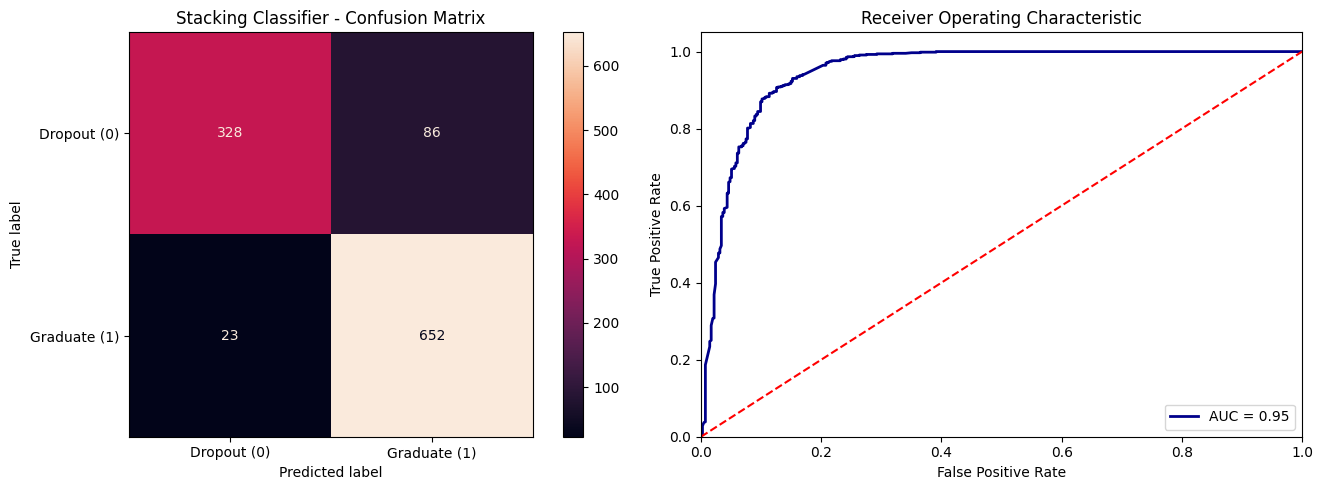

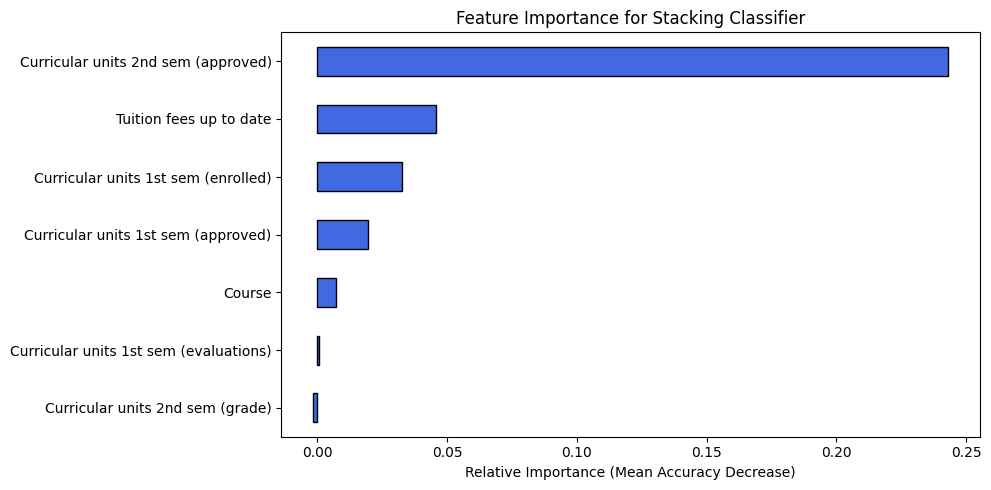

In [ ]:
from sklearn.ensemble import StackingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

# Define the base models specified in the paper
base_models = [
    ('adaboost', AdaBoostClassifier(n_estimators=50, random_state=42, algorithm='SAMME')),
    ('gradboost', GradientBoostingClassifier(n_estimators=100, random_state=42))
]

# Initialize the Stacking Classifier with a Logistic Regression meta-model
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

# Train the model
stacking_model.fit(X_train, y_train)

# Evaluate and plot standard metrics using our helper function
evaluate_and_visualize(stacking_model, X_test, y_test, "Stacking Classifier")

# Calculate Permutation Importance for the Stacking Classifier
result = permutation_importance(
    stacking_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Plot Feature Importance
plt.figure(figsize=(10, 5))
stacking_importances = pd.Series(result.importances_mean, index=X_test.columns)
stacking_importances.sort_values(ascending=True).plot(
    kind='barh',
    color='royalblue',
    edgecolor='black'
)
plt.title('Feature Importance for Stacking Classifier')
plt.xlabel('Relative Importance (Mean Accuracy Decrease)')
plt.tight_layout()
plt.show()